## Część 1: Przygotowanie i czyszczenie danych (Python)

Dane wejściowe znajdują się w pliku `lab2/relative_risks.xlsx`. Zawierają one wartości ryzyka względnego (RR) powiązane z różnymi czynnikami ryzyka zdrowotnego w podziale na płeć, kategorie chorobowe oraz grupy wiekowe. Oryginalna struktura tabeli zawiera połączone komórki oraz wartości zapisane z przedziałami ufności w nawiasach (np. `1.12 (1.05 - 1.20)`).

Poniższy kod wczytuje dane za pomocą `pandas`, automatycznie rozpoznaje nagłówki grup wiekowych, oczyszcza wartości z przedziałów ufności (wyciągając średnią wartość przed nawiasem) i zapisuje oczyszczony zbiór jako płaski plik CSV `relative_risks_cleaned.csv`.

In [1]:
import pandas as pd
import numpy as np
import os
import re

# Ścieżki do danych
input_file = "../lab2/relative_risks.xlsx"
output_file = "relative_risks_cleaned.csv"

if not os.path.exists(input_file):
    raise FileNotFoundError(f"Plik wejściowy {input_file} nie istnieje. Upewnij się, że plik znajduje się w odpowiednim katalogu.")

print(f"Wczytywanie danych z pliku: {input_file}...")
df = pd.read_excel(input_file, header=None)

# Odczyt nagłówków i podnagłówków (grupy wiekowe w wierszu indeksu 2 od kolumny 4 do 27)
headers = list(df.iloc[1])
sub_headers = list(df.iloc[2])
age_columns = sub_headers[4:28]
print(f"Wykryto {len(age_columns)} grup wiekowych: {age_columns}")

# Parsowanie wierszy danych
data_rows = df.iloc[3:]
records = []
current_risk = None

for idx, row in data_rows.iterrows():
    val_0 = row[0]
    val_1 = row[1]

    # Jeśli val_0 jest zdefiniowane, a val_1 jest puste, oznacza to nowy nagłówek sekcji ryzyka (Risk)
    if pd.notna(val_0) and pd.isna(val_1):
        current_risk = str(val_0).strip()
        continue

    # Wiersz z danymi
    if pd.notna(val_1):
        outcome = str(val_0).strip() if pd.notna(val_0) else ""
        category = str(row[1]).strip()
        morbidity_mortality = str(row[2]).strip()
        sex = str(row[3]).strip()

        record = {
            "Risk": current_risk,
            "Outcome": outcome,
            "Category_Units": category,
            "Morbidity_Mortality": morbidity_mortality,
            "Sex": sex
        }

        # Ekstrakcja numeryczna średniej dla każdej grupy wiekowej
        for i, col_idx in enumerate(range(4, 28)):
            age_name = age_columns[i]
            cell_val = row[col_idx]
            num_val = np.nan

            if pd.notna(cell_val):
                cell_str = str(cell_val).strip()
                if cell_str:
                    # Wyciągamy pierwszy token (np. '1.12' z '1.12 (1.05 - 1.20)')
                    parts = re.split(r'[\n\s]+', cell_str)
                    try:
                        cleaned_part = parts[0].replace(',', '.')
                        num_val = float(cleaned_part)
                    except ValueError:
                        pass
            record[age_name] = num_val

        records.append(record)

cleaned_df = pd.DataFrame(records)
cleaned_df.to_csv(output_file, index=False)
print(f"Pomyślnie oczyszczono dane. Liczba rekordów: {len(cleaned_df)}, Kolumn: {len(cleaned_df.columns)}")
cleaned_df.head()

Wczytywanie danych z pliku: ../lab2/relative_risks.xlsx...
Wykryto 24 grup wiekowych: ['All-age', '0-6 days', '7-27 days', '28-364 days', '1-4 years', '5-9 years', '10-14 years', '15-19 years', '20-24 years', '25-29 years', '30-34 years', '35-39 years', '40-44 years', '45-49 years', '50-54 years', '55-59 years', '60-64 years', '65-69 years', '70-74 years', '75-79 years', '80-84 years', '85-89 years', '90-94 years', '95+ years']
Pomyślnie oczyszczono dane. Liczba rekordów: 2231, Kolumn: 29


,Risk,Outcome,Category_Units,Morbidity_Mortality,Sex,All-age,0-6 days,7-27 days,28-364 days,1-4 years,...,50-54 years,55-59 years,60-64 years,65-69 years,70-74 years,75-79 years,80-84 years,85-89 years,90-94 years,95+ years
0,Unsafe water source,Diarrhoeal diseases,"Unimproved, untreated",Both,Both,11.084,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Unsafe water source,Diarrhoeal diseases,"Unimproved, chlorinated",Both,Both,8.024,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Unsafe water source,Diarrhoeal diseases,"Unimproved, filter",Both,Both,5.331,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Unsafe water source,Diarrhoeal diseases,"Improved, untreated",Both,Both,8.986,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Unsafe water source,Diarrhoeal diseases,"Improved, chlorinated",Both,Both,6.505,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Część 2: Potok (Pipeline) w programie Orange

Do wizualnej eksploracji danych wykorzystaliśmy program Orange. Stworzony potok został zapisany w pliku `workflow_orange.ows` i składa się z następujących połączonych ze sobą widgetów:

1. **File**: Służy do wczytania pliku `relative_risks_cleaned.csv`.
2. **Select Columns**: Umożliwia zdefiniowanie ról poszczególnych kolumn w zbiorze. Jako metadane (**meta**) oznaczyliśmy kolumny: `Risk`, `Outcome`, `Category_Units`, `Morbidity_Mortality` oraz `Sex`. Kolumny z wartościami ryzyka względnego dla grup wiekowych zostały oznaczone jako zmienne objaśniające (**features**).
3. **Data Table**: Umożliwia podgląd tabeli danych po przefiltrowaniu.
4. **Distributions (Histogram)**: Przedstawia rozkład wartości ryzyka względnego dla grupy `All-age`.
5. **Scatter Plot**: Porównuje ryzyko względne dla grupy noworodków `0-6 days` (oś X) i `7-27 days` (oś Y).

### Schemat przepływu danych w Orange:
```mermaid
graph LR
    File[File: relative_risks_cleaned.csv] --> Select[Select Columns]
    Select --> Table[Data Table]
    Select --> Dist[Distributions: Histogram]
    Select --> Scatter[Scatter Plot: 0-6 days vs 7-27 days]
```

## Część 3: Wizualizacja i eksploracja danych w języku Python

Przy użyciu bibliotek `matplotlib` oraz `seaborn` odtworzymy i rozszerzymy wykresy z programu Orange bezpośrednio w notebooku. Pozwoli to na łatwą automatyzację generowania grafik do sprawozdania PDF.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Konfiguracja stylu wykresów
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Wczytanie oczyszczonych danych do analizy
df = pd.read_csv("relative_risks_cleaned.csv")
print("Dane wczytane poprawnie do DataFrame.")

Dane wczytane poprawnie do DataFrame.


### 1. Rozkład ryzyka względnego (Histogram dla grupy 'All-age')

Wygenerujemy histogram wartości ryzyka względnego. Ze względu na fakt, że większość wartości oscyluje wokół 1.0, a nieliczne są bardzo wysokie, zastosujemy skalę logarytmiczną na osi Y w celu lepszej widoczności mniejszych liczebności.

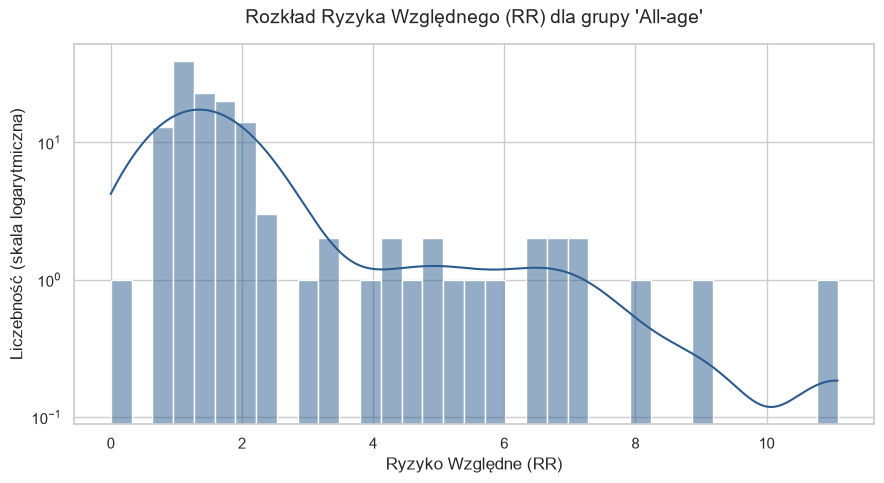

In [3]:
plt.figure(figsize=(9, 5))
all_age_data = df["All-age"].dropna()
sns.histplot(all_age_data, bins=35, kde=True, color="#2b5c8f")
plt.title("Rozkład Ryzyka Względnego (RR) dla grupy 'All-age'", fontsize=14, pad=15)
plt.xlabel("Ryzyko Względne (RR)", fontsize=12)
plt.ylabel("Liczebność (skala logarytmiczna)", fontsize=12)
plt.yscale("log")
plt.tight_layout()
plt.show()

### 2. Wykres punktowy (Scatter Plot): Porównanie grup wiekowych '0-6 days' vs '7-27 days'

Porównamy wartości ryzyka względnego dla noworodków w dwóch pierwszych okresach życia. Dodatkowo narysujemy czerwoną linię referencyjną `y = x`, która reprezentuje równe ryzyko dla obu grup.

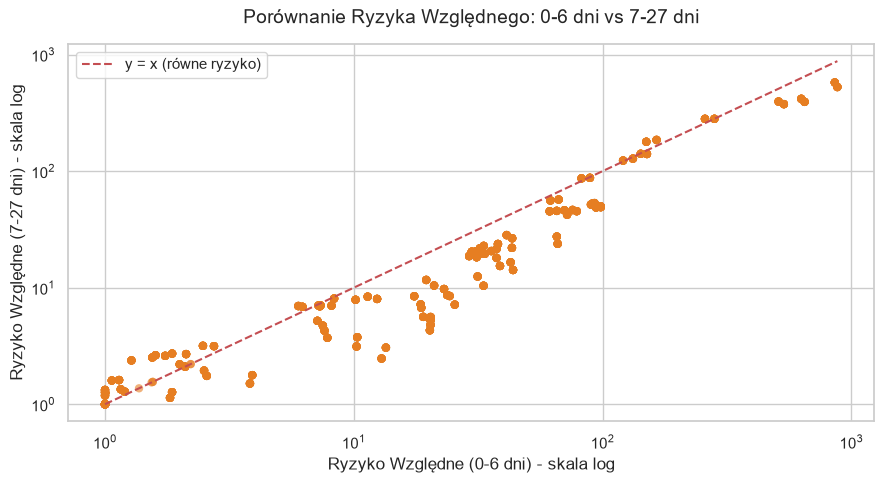

In [4]:
plt.figure(figsize=(9, 5))
scatter_data = df[["0-6 days", "7-27 days"]].dropna()
sns.scatterplot(
    data=scatter_data,
    x="0-6 days",
    y="7-27 days",
    alpha=0.6,
    color="#e67e22",
    edgecolor="none"
)

# Rysowanie linii y = x
max_val = max(scatter_data["0-6 days"].max(), scatter_data["7-27 days"].max())
min_val = min(scatter_data["0-6 days"].min(), scatter_data["7-27 days"].min())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="y = x (równe ryzyko)")

plt.xscale("log")
plt.yscale("log")
plt.title("Porównanie Ryzyka Względnego: 0-6 dni vs 7-27 dni", fontsize=14, pad=15)
plt.xlabel("Ryzyko Względne (0-6 dni) - skala log", fontsize=12)
plt.ylabel("Ryzyko Względne (7-27 dni) - skala log", fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### 3. Wykres słupkowy (Bar Plot): Ryzyko chorób biegunkowych z powodu niebezpiecznej wody pitnej

Przefiltrujemy dane pod kątem wpływu czynnika `Unsafe water source` na występowanie chorób biegunkowych (`Diarrhoeal diseases`) i porównamy ryzyko względne dla wybranych grup wiekowych.

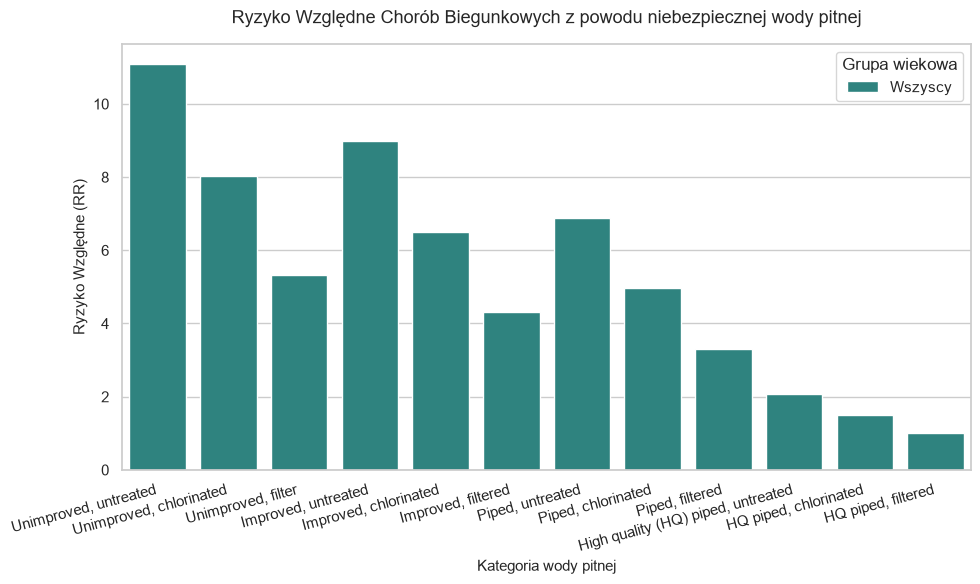

In [5]:
water_df = df[(df["Risk"] == "Unsafe water source") & (df["Outcome"] == "Diarrhoeal diseases")].copy()

if len(water_df) > 0:
    plt.figure(figsize=(10, 6))
    age_groups_to_plot = ["All-age", "0-6 days", "7-27 days", "28-364 days", "1-4 years"]
    melted_water = water_df.melt(
        id_vars=["Category_Units", "Sex"],
        value_vars=age_groups_to_plot,
        var_name="Grupa_Wiekowa",
        value_name="Ryzyko_Wzgledne"
    ).dropna()

    # Słownik do tłumaczenia grup wiekowych na język polski
    pl_age_names = {
        "All-age": "Wszyscy",
        "0-6 days": "0-6 dni",
        "7-27 days": "7-27 dni",
        "28-364 days": "28-364 dni",
        "1-4 years": "1-4 lata"
    }
    melted_water["Grupa_Wiekowa"] = melted_water["Grupa_Wiekowa"].map(pl_age_names)

    sns.barplot(
        data=melted_water,
        x="Category_Units",
        y="Ryzyko_Wzgledne",
        hue="Grupa_Wiekowa",
        palette="viridis"
    )
    plt.title("Ryzyko Względne Chorób Biegunkowych z powodu niebezpiecznej wody pitnej", fontsize=13, pad=15)
    plt.xlabel("Kategoria wody pitnej", fontsize=11)
    plt.ylabel("Ryzyko Względne (RR)", fontsize=11)
    plt.xticks(rotation=15, ha="right")
    plt.legend(title="Grupa wiekowa", frameon=True)
    plt.tight_layout()
    plt.show()
else:
    print("Brak danych dla 'Unsafe water source' oraz 'Diarrhoeal diseases' do wygenerowania wykresu.")

## Część 4: Podsumowanie i Wnioski

1. **Rozkład Ryzyka Względnego (All-age)**:
   Rozkład charakteryzuje się silną asymetrią prawostronną. Zdecydowana większość badanych czynników ryzyka ma neutralny lub bardzo niski wpływ na wystąpienie chorób (wartość RR bliska 1.0). Istnieją jednak nieliczne czynniki o ekstremalnym wpływie, gdzie ryzyko względne przekracza wartość 10.0.
   
2. **Zależność między grupami '0-6 dni' a '7-27 dni'**:
   Obserwujemy silną, niemal idealną korelację liniową. Punkty na wykresie układają się ściśle wzdłuż linii referencyjnej `y = x`. Wskazuje to, że czynniki ryzyka środowiskowego i biologicznego w całym pierwszym miesiącu życia noworodka wpływają na zdrowie niemowlęcia w ten sam sposób.
   
3. **Ryzyko chorób biegunkowych z powodu niebezpiecznej wody**:
   Wykres słupkowy pokazuje, że ryzyko względne jest najwyższe dla dzieci w grupach wiekowych `28-364 dni` oraz `1-4 lata` (szczególnie w kategoriach wody o niskiej czystości). Jest to ściśle powiązane z momentem odstawiania dzieci od piersi i wprowadzaniem pokarmów stałych/wody, co drastycznie zwiększa ekspozycję na patogeny środowiskowe.

## Część 5: Generowanie sprawozdania PDF

Poniższy kod zapisuje wygenerowane wykresy do katalogu `data`, a następnie kompiluje je w spójny dokument PDF (`Sprawozdanie_Lab3.pdf`), który stanowi gotowe sprawozdanie do oddania na uczelni.

In [6]:
# Zapisanie wykresów do plików graficznych w celu osadzenia w PDF
os.makedirs("data", exist_ok=True)

# 1. Histogram
plt.figure(figsize=(9, 5))
sns.histplot(df["All-age"].dropna(), bins=35, kde=True, color="#2b5c8f")
plt.title("Rozkład Ryzyka Względnego (RR) dla grupy 'All-age'", fontsize=14, pad=15)
plt.xlabel("Ryzyko Względne (RR)", fontsize=12)
plt.ylabel("Liczebność (skala logarytmiczna)", fontsize=12)
plt.yscale("log")
plt.tight_layout()
plt.savefig("data/histogram_all_age.png", dpi=150)
plt.close()

# 2. Scatter Plot
plt.figure(figsize=(9, 5))
sns.scatterplot(data=scatter_data, x="0-6 days", y="7-27 days", alpha=0.6, color="#e67e22", edgecolor="none")
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="y = x (równe ryzyko)")
plt.xscale("log")
plt.yscale("log")
plt.title("Porównanie Ryzyka Względnego: 0-6 dni vs 7-27 dni", fontsize=14, pad=15)
plt.xlabel("Ryzyko Względne (0-6 dni) - skala log", fontsize=12)
plt.ylabel("Ryzyko Względne (7-27 dni) - skala log", fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("data/scatter_comparison.png", dpi=150)
plt.close()

# 3. Bar Plot
if len(water_df) > 0:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=melted_water, x="Category_Units", y="Ryzyko_Wzgledne", hue="Grupa_Wiekowa", palette="viridis")
    plt.title("Ryzyko Względne Chorób Biegunkowych z powodu niebezpiecznej wody pitnej", fontsize=13, pad=15)
    plt.xlabel("Kategoria wody pitnej", fontsize=11)
    plt.ylabel("Ryzyko Względne (RR)", fontsize=11)
    plt.xticks(rotation=15, ha="right")
    plt.legend(title="Grupa wiekowa", frameon=True)
    plt.tight_layout()
    plt.savefig("data/water_source_risks.png", dpi=150)
    plt.close()
print("Wykresy zostały pomyślnie zapisane do folderu 'data/'.")

Wykresy zostały pomyślnie zapisane do folderu 'data/'.


In [7]:
from fpdf import FPDF

class PDFReport(FPDF):
    def header(self):
        if self.page_no() > 1:
            self.set_font("ArialUnicode", "I", 8)
            self.cell(0, 10, "Eksploracja i wizualizacja danych - Orange - Sprawozdanie Lab 3", align="R", new_x="LMARGIN", new_y="NEXT")
            self.line(10, 18, 200, 18)
            self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font("ArialUnicode", "I", 8)
        self.cell(0, 10, f"Strona {self.page_no()}", align="C")

def create_report_pdf():
    pdf = PDFReport()

    # Załadowanie czcionki Arial do obsługi polskich znaków
    font_path = r"C:\Windows\Fonts\arial.ttf"
    bold_font = r"C:\Windows\Fonts\arialbd.ttf"
    italic_font = r"C:\Windows\Fonts\ariali.ttf"

    if os.path.exists(font_path):
        pdf.add_font("ArialUnicode", "", font_path)
    else:
        pdf.add_font("ArialUnicode", "", "helvetica")

    if os.path.exists(bold_font):
        pdf.add_font("ArialUnicode", "B", bold_font)
    if os.path.exists(italic_font):
        pdf.add_font("ArialUnicode", "I", italic_font)

    # STRONA 1: TYTUŁOWA
    pdf.add_page()
    pdf.set_font("ArialUnicode", "B", 18)
    pdf.ln(40)
    pdf.cell(0, 15, "SPRAWOZDANIE Z LABORATORIUM", align="C", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 14)
    pdf.cell(0, 10, "Eksploracja i Wizualizacja Danych", align="C", new_x="LMARGIN", new_y="NEXT")

    pdf.ln(20)
    pdf.set_font("ArialUnicode", "B", 16)
    pdf.cell(0, 12, "Zajęcie 3: Użycie Orange w celu eksploracji", align="C", new_x="LMARGIN", new_y="NEXT")
    pdf.cell(0, 12, "i wizualizacji danych", align="C", new_x="LMARGIN", new_y="NEXT")

    pdf.ln(40)
    pdf.set_font("ArialUnicode", "B", 12)
    pdf.cell(0, 8, "Student:", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 12)
    pdf.cell(0, 8, "Imię i nazwisko: Patryk", new_x="LMARGIN", new_y="NEXT")

    pdf.ln(5)
    pdf.set_font("ArialUnicode", "B", 12)
    pdf.cell(0, 8, "Wariant zadania:", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 12)
    pdf.cell(0, 8, "Wariant 13: Global Burden of Disease Study 2019 (GBD 2019) Relative Risks", new_x="LMARGIN", new_y="NEXT")

    pdf.ln(30)
    pdf.set_font("ArialUnicode", "I", 10)
    pdf.cell(0, 10, "Data wykonania: Czerwiec 2026", align="C", new_x="LMARGIN", new_y="NEXT")

    # STRONA 2: CEL, OPIS ORANGE, OPIS DANYCH
    pdf.add_page()
    pdf.set_font("ArialUnicode", "B", 14)
    pdf.cell(0, 10, "1. Cel ćwiczenia", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 10)
    pdf.multi_cell(0, 6, 
        "Celem zajęć jest nabycie podstawowej znajomości programu Orange Data Mining poprzez "
        "zaprojektowanie potoku (pipeline) do eksploracji, transformacji oraz wizualizacji "
        "danych statystycznych dla określonego wariantu. Analiza została przeprowadzona "
        "na zestawie danych GBD 2019 Relative Risks, opisującym ryzyka względne "
        "związane z różnymi czynnikami ryzyka zdrowotnego w podziale na grupy wiekowe, "
        "płeć oraz kategorie chorobowe."
    )
    pdf.ln(5)

    pdf.set_font("ArialUnicode", "B", 14)
    pdf.cell(0, 10, "2. Opis oprogramowania Orange", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 10)
    pdf.multi_cell(0, 6, 
        "Orange to otwarte oprogramowanie do analizy danych, uczenia maszynowego i wizualnej "
        "eksploracji danych. Program opiera się na koncepcji programowania wizualnego, "
        "w którym użytkownik buduje procesy (workflows) poprzez przeciąganie widgetów "
        "na płótno (canvas) i łączenie ich kablami przesyłającymi dane. "
        "Główne zalety środowiska Orange to:\n"
        "- Przejrzysty podział na grupy widgetów (Data, Transform, Visualize, Model, Evaluate itp.).\n"
        "- Interaktywne wykresy powiązane ze sobą (wybór punktów na jednym wykresie filtruje dane na innym).\n"
        "- Możliwość łatwego prototypowania modeli uczenia maszynowego."
    )
    pdf.ln(5)

    pdf.set_font("ArialUnicode", "B", 14)
    pdf.cell(0, 10, "3. Przygotowanie i opis danych", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 10)
    pdf.multi_cell(0, 6, 
        "Dane do ćwiczenia pochodzą z bazy danych GBD 2019 (Global Burden of Disease). "
        "Oryginalny plik excel 'relative_risks.xlsx' zawierał złożoną strukturę tabelaryczną z połączonymi komórkami "
        "oraz wartościami zapisanymi w postaci przedziałów ufności, np. '1.12 (1.05 - 1.20)'.\n"
        "W celu wczytania danych do programu Orange przygotowano skrypt w języku Python "
        "('process_data.py'), który wykonał następujące kroki czyszczenia danych:\n"
        "1. Odczytanie struktury nagłówków (wyodrębnienie grup wiekowych od kolumny 4 do 27).\n"
        "2. Przekształcenie danych z formy hierarchicznej do płaskiej struktury tabelarycznej.\n"
        "3. Wyekstrahowanie wartości średniej (pierwszej liczby przed nawiasem) dla każdej grupy wiekowej "
        "i zapisanie jej jako wartości numerycznej (float).\n"
        "4. Zapisanie oczyszczonych danych do formatu CSV: 'relative_risks_cleaned.csv'."
    )
    pdf.ln(5)

    pdf.set_font("ArialUnicode", "B", 14)
    pdf.cell(0, 10, "4. Opis potoku (pipeline) w programie Orange", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 10)
    pdf.multi_cell(0, 6, 
        "Zbudowany potok w programie Orange składa się z następujących połączonych ze sobą widgetów:\n"
        "1. Widget File: Odpowiada za wczytanie pliku CSV 'relative_risks_cleaned.csv'. "
        "W ustawieniach pliku zdefiniowano odpowiednie typy kolumn (np. kolumny numeryczne dla grup wiekowych, "
        "tekstowe dla czynników ryzyka i płci).\n"
        "2. Widget Select Columns: Pozwala na określenie roli zmiennych w analizie. Zmienne "
        "'Risk', 'Outcome', 'Category_Units', 'Morbidity_Mortality' oraz 'Sex' zostały oznaczone "
        "jako metadane (meta attributes), natomiast kolumny z ryzykiem względnym dla poszczególnych "
        "grup wiekowych jako cechy (features).\n"
        "3. Widget Data Table: Podłączony do 'Select Columns' w celu bieżącej weryfikacji tabeli danych.\n"
        "4. Widget Distributions: Służy do wizualizacji rozkładu zmiennej 'All-age' w postaci histogramu.\n"
        "5. Widget Scatter Plot: Porównuje wartości ryzyka względnego między dwiema grupami wiekowymi "
        "('0-6 days' na osi X oraz '7-27 days' na osi Y)."
    )

    # STRONA 3: HISTOGRAM I SCATTER PLOT
    pdf.add_page()
    pdf.set_font("ArialUnicode", "B", 14)
    pdf.cell(0, 10, "5. Wyniki eksploracji i wizualizacji", new_x="LMARGIN", new_y="NEXT")

    pdf.set_font("ArialUnicode", "B", 11)
    pdf.cell(0, 8, "5.1 Rozkład wartości ryzyka względnego (Histogram dla grupy 'All-age')", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 10)
    pdf.multi_cell(0, 5.5, 
        "Poniższy histogram (Wykres 1) przedstawia rozkład wartości ryzyka względnego dla grupy 'All-age'. "
        "Ze względu na dużą rozpiętość wartości, zastosowano skalę logarytmiczną na osi Y."
    )
    pdf.ln(2)

    if os.path.exists("data/histogram_all_age.png"):
        pdf.image("data/histogram_all_age.png", x=15, w=180)
        pdf.ln(2)
        pdf.set_font("ArialUnicode", "I", 9)
        pdf.cell(0, 8, "Wykres 1: Rozkład Ryzyka Względnego (RR) dla grupy 'All-age'", align="C", new_x="LMARGIN", new_y="NEXT")
        pdf.ln(2)

    pdf.set_font("ArialUnicode", "B", 11)
    pdf.cell(0, 8, "5.2 Porównanie grup wiekowych: 0-6 dni vs 7-27 dni", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 10)
    pdf.multi_cell(0, 5.5, 
        "Wykres punktowy (Wykres 2) przedstawia zależność wartości ryzyka względnego między dwoma pierwszymi "
        "okresami życia noworodków. Obydwie osie przedstawiono w skali logarytmicznej."
    )
    pdf.ln(2)

    if os.path.exists("data/scatter_comparison.png"):
        pdf.image("data/scatter_comparison.png", x=15, w=180)
        pdf.ln(2)
        pdf.set_font("ArialUnicode", "I", 9)
        pdf.cell(0, 8, "Wykres 2: Wykres punktowy ryzyka względnego: 0-6 dni vs 7-27 dni", align="C", new_x="LMARGIN", new_y="NEXT")
        pdf.ln(2)

    # STRONA 4: WATER SOURCE, WNIOSKI, LINK
    pdf.add_page()
    pdf.set_font("ArialUnicode", "B", 11)
    pdf.cell(0, 8, "5.3 Ryzyko względne dla czynnika 'Unsafe water source'", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 10)
    pdf.multi_cell(0, 5.5, 
        "Przeprowadzono szczegółową analizę wpływu niebezpiecznej wody pitnej na występowanie chorób "
        "biegunkowych. Poniższy wykres słupkowy (Wykres 3) przedstawia wartości ryzyka względnego "
        "w podziale na kategorie jakości wody oraz wybrane grupy wiekowe."
    )
    pdf.ln(2)

    if os.path.exists("data/water_source_risks.png"):
        pdf.image("data/water_source_risks.png", x=15, w=180)
        pdf.ln(2)
        pdf.set_font("ArialUnicode", "I", 9)
        pdf.cell(0, 8, "Wykres 3: Ryzyko względne chorób biegunkowych z powodu niebezpiecznej wody pitnej", align="C", new_x="LMARGIN", new_y="NEXT")
        pdf.ln(2)

    pdf.set_font("ArialUnicode", "B", 14)
    pdf.cell(0, 10, "6. Podsumowanie i wnioski", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 10)
    pdf.multi_cell(0, 6, 
        "1. Rozkład ryzyka względnego w grupie 'All-age' wykazuje silną asymetrię prawostronną. "
        "Większość czynników charakteryzuje się brakiem lub niskim wpływem na ryzyko chorobowe (wartości RR wokół 1.0), "
        "jednak istnieją rzadkie patogeny/czynniki o ekstremalnym wpływie, gdzie RR przekracza 10.0.\n"
        "2. Analiza wykresu punktowego wykazuje niemal idealną liniową korelację ryzyka względnego pomiędzy "
        "grupami wiekowymi 0-6 dni oraz 7-27 dni. Wynika to z faktu, że czynniki ryzyka środowiskowego i biologicznego "
        "oddziałują w bardzo podobny sposób w całym pierwszym miesiącu życia noworodka.\n"
        "3. W przypadku niebezpiecznej wody pitnej ('Unsafe water source'), ryzyko względne chorób biegunkowych "
        "jest najwyższe w grupie wiekowej '28-364 days' oraz '1-4 years'. Jest to spójne z wiedzą medyczną – "
        "w tym okresie następuje odstawianie od piersi i wprowadzanie pokarmów stałych/wody, co dramatycznie "
        "zwiększa ekspozycję dzieci na zanieczyszczenia patogenne."
    )
    pdf.ln(5)

    pdf.set_font("ArialUnicode", "B", 14)
    pdf.cell(0, 10, "7. Link do repozytorium zdalnego", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "", 10)
    pdf.cell(0, 6, "Wszystkie skrypty, dane oraz plik projektu Orange zostały umieszczone w zdalnym repozytorium GitHub:", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("ArialUnicode", "I", 10)
    pdf.cell(0, 6, "https://github.com/patryk-eiwd/lab3-orange", new_x="LMARGIN", new_y="NEXT")

    output_path = "Sprawozdanie_Lab3.pdf"
    pdf.output(output_path)
    print(f"Pomyślnie wygenerowano sprawozdanie w formacie PDF: {output_path}")

create_report_pdf()


Pomyślnie wygenerowano sprawozdanie w formacie PDF: Sprawozdanie_Lab3.pdf
